In [1]:
import os

In [2]:
# configurations
CONFIG = {
    'data_dir': 'ct_up_threshold_0.8',

     # A: Adenocarcinoma, B: Small Cell, E: Large Cell, G: Squamous Cell
    'classes': ['A', 'B', 'E', 'G'],
    'class_names': ['Adenocarcinoma', 'Small Cell', 'Large Cell', 'Squamous Cell'],
    'image_size': 128,

    # number of slices per sequence
    'seq_length': 8,  
    'batch_size': 4,
    'num_epochs':30,
    'learning_rate': 1e-4,
    'num_workers': 0,

    # save model checkpoint and test data split
    'model_save_dir': 'ct_up_8'
}

# create model save directory
os.makedirs(CONFIG['model_save_dir'], exist_ok=True)

print('[ ] Configurations:\n')
for key, value in CONFIG.items():
    print(f'  {key}: {value}')

[ ] Configurations:

  data_dir: ct_up_threshold_0.8
  classes: ['A', 'B', 'E', 'G']
  class_names: ['Adenocarcinoma', 'Small Cell', 'Large Cell', 'Squamous Cell']
  image_size: 128
  seq_length: 8
  batch_size: 4
  num_epochs: 30
  learning_rate: 0.0001
  num_workers: 0
  model_save_dir: ct_up_8


In [3]:
import random
import numpy as np
import torch

# set reproducibility state
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# detect device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f'Device selected: {device}')

Device selected: cuda


In [4]:
import json

In [5]:
from torch.utils.data import Dataset
from pathlib import Path
from PIL import Image
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode

In [6]:
class CTSequenceDataset(Dataset):
    """
    Dataset class for CT sequences.
    Each sequence is from a .npy file.
    Returns all slices for classification.
    """
    
    def __init__(self, data_dir, classes, seq_length=8, image_size=128):
        self.data_dir = Path(data_dir)
        self.classes = classes
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        self.seq_length = seq_length
        self.image_size = image_size
        self.sequences = []
        
        # load all sequences
        for cls in classes:
            cls_dir = self.data_dir / cls
            if not cls_dir.exists():
                print(f'Warning: Directory {cls_dir} does not exist')
                continue
            
            for npy_file in sorted(cls_dir.glob("*.npy")):
                vol = np.load(npy_file)
                
                # split volume into sequences
                n_full = vol.shape[0] // self.seq_length
                for i in range(n_full):
                    start = i * self.seq_length
                    chunk = vol[start:start + self.seq_length]
                    
                    if chunk.shape[0] == self.seq_length:

                        # store original (non-augmented) sequence
                        self.sequences.append({
                            'sequence': chunk.astype(np.float32),
                            'label': self.class_to_idx[cls],
                            'class': cls,
                            'file': npy_file.name,
                            'is_augmented': False
                        })
                        
        
        print(f'[ ] Loaded {len(self.sequences)} sequences\n')
        for cls in classes:
            count = sum(1 for s in self.sequences if s['class'] == cls)
            pct = (count/len(self.sequences)*100) if len(self.sequences) else 0
            print(f"  {cls}: {count} sequences ({pct:.1f}%)")
    
    def augment(self, img, p=0.5):

        # convert numpy array to PIL Image
        if not isinstance(img, Image.Image):
            img = Image.fromarray(img)

        if p > 0:
            # horizontal flip
            if random.random() > 0.5:
                img = TF.hflip(img)

            # rotation ±10 degrees
            if random.random() > 0.5:
                angle = random.uniform(-10, 10)
                img = TF.rotate(img, angle, interpolation=InterpolationMode.BILINEAR)

            # brightness adjust 0.9 - 1.1
            if random.random() > 0.5:
                factor = random.uniform(0.9, 1.1)
                img = TF.adjust_brightness(img, factor)

        return img
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        item = self.sequences[idx]
        sequence = item['sequence']  # Shape: (seq_length, H, W), range [0, 1]
        label = item['label']
        
        # convert each slice to PIL and then to RGB
        imgs = []
        for i in range(self.seq_length):
            slice_2d = sequence[i]
            slice_uint8 = (slice_2d * 255).astype(np.uint8)
            img_pil = Image.fromarray(slice_uint8).convert('RGB')
            imgs.append(img_pil)
        
        return imgs, label

In [7]:
import matplotlib.pyplot as plt

In [8]:
# create the full dataset
full_dataset = CTSequenceDataset(
    data_dir=CONFIG['data_dir'],
    classes=CONFIG['classes'],
    seq_length=CONFIG['seq_length'],
    image_size=CONFIG['image_size'],
)

print('\n[ ] Dataset Characteristics\n')
print(f'  {"Class":<20} {"Patients":>10} {"CT 2D":>12}')
print(f'  {"-"*50}')
for cls, cls_name in zip(CONFIG['classes'], CONFIG['class_names']):
    cls_seqs = [s for s in full_dataset.sequences if s['class'] == cls]
    cls_patients = len({s['file'] for s in cls_seqs})
    sample_count = len(cls_seqs) * 8
    print(f'  {cls_name:<20} {cls_patients:>10} {sample_count:>12}')

[ ] Loaded 3918 sequences

  A: 2887 sequences (73.7%)
  B: 297 sequences (7.6%)
  E: 12 sequences (0.3%)
  G: 722 sequences (18.4%)

[ ] Dataset Characteristics

  Class                  Patients        CT 2D
  --------------------------------------------------
  Adenocarcinoma              245        23096
  Small Cell                   37         2376
  Large Cell                    5           96
  Squamous Cell                61         5776


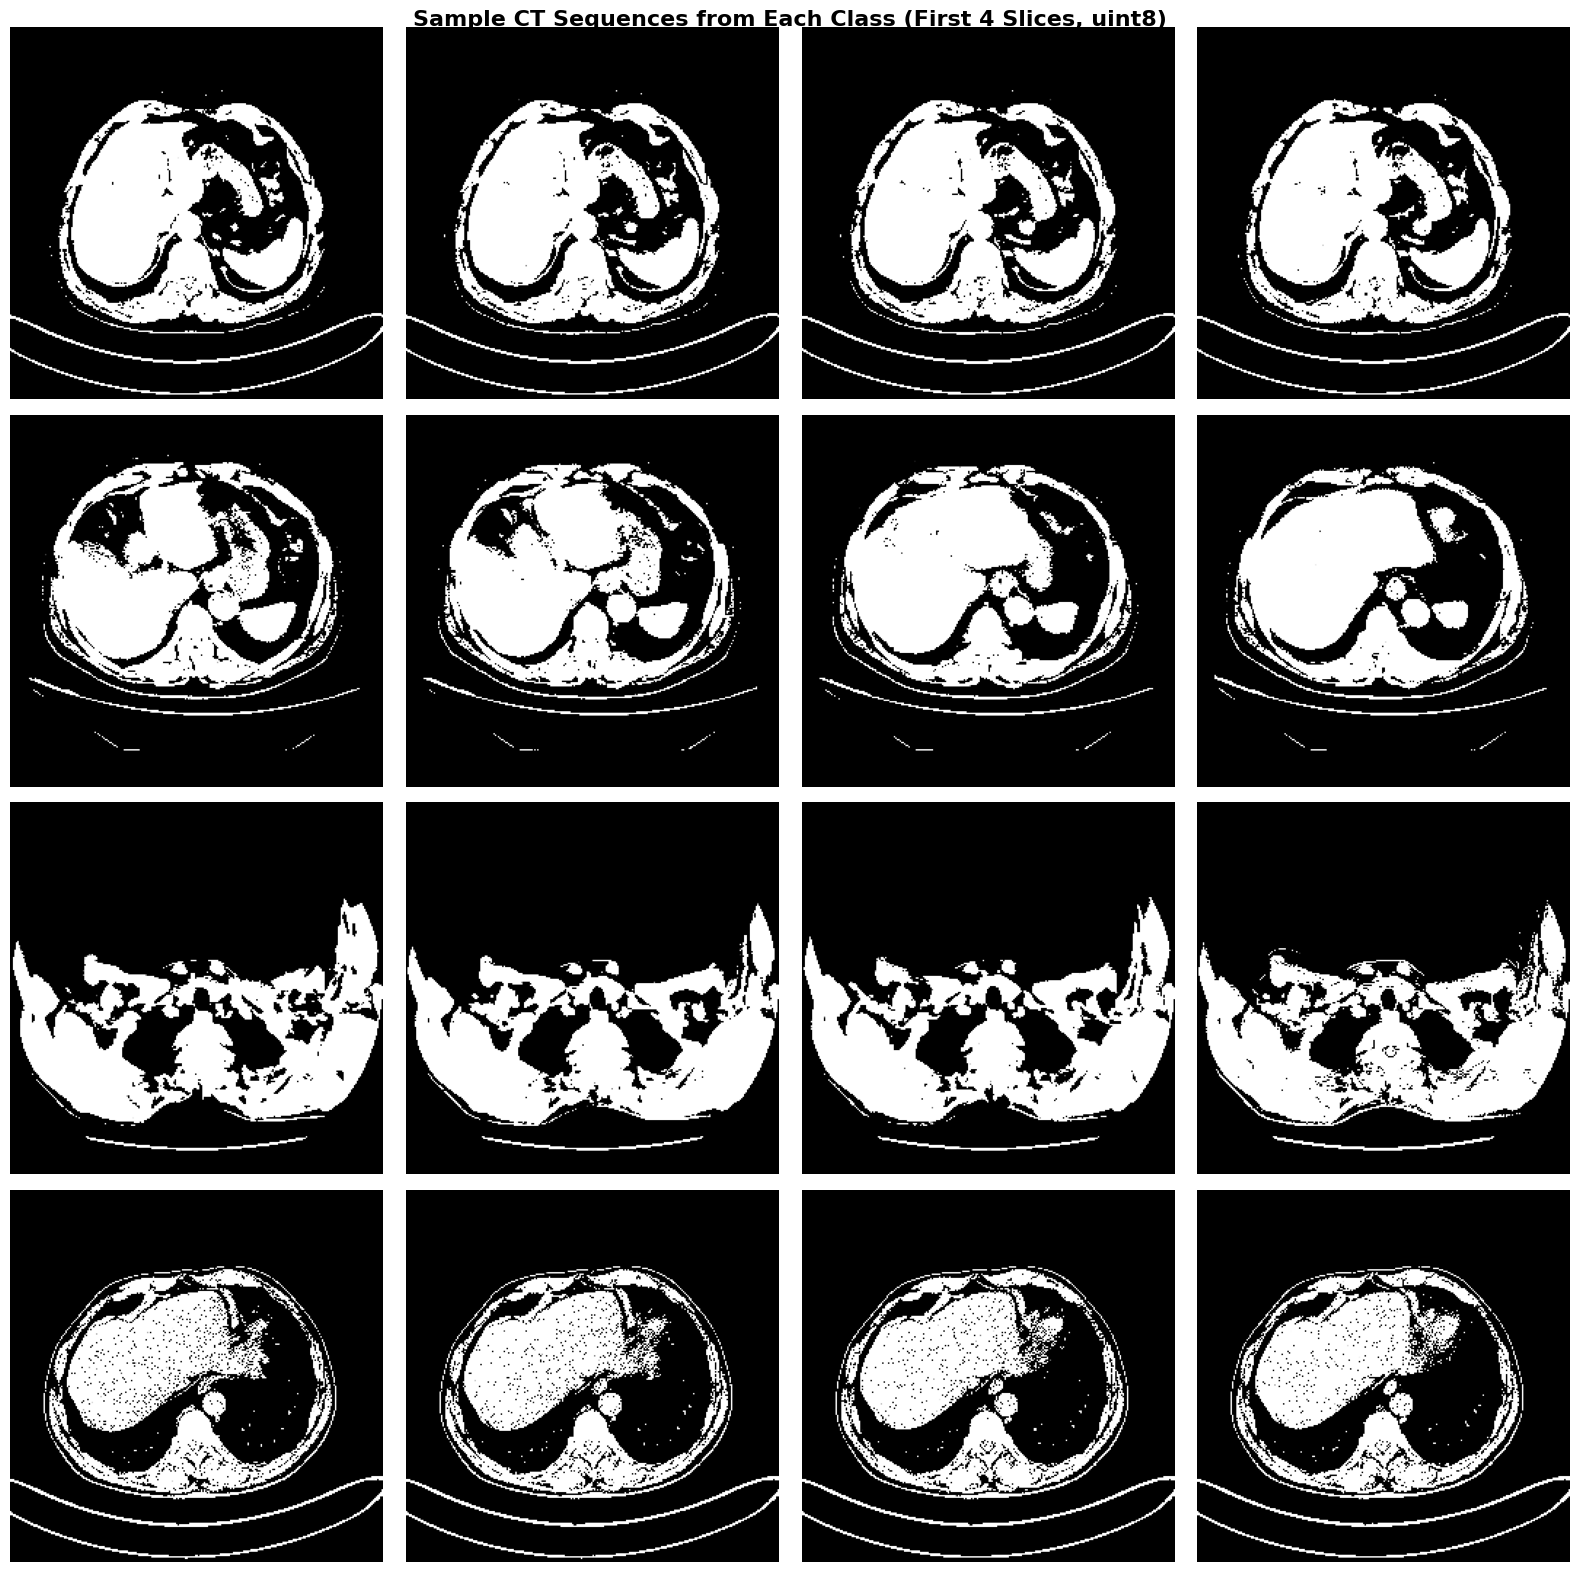

In [9]:
# visualize sample CT slices from each class (uint8)
fig, axes = plt.subplots(len(CONFIG['classes']), 4, figsize=(16, len(CONFIG['classes']) * 4))

slices_per_seq = 4

for cls_idx, cls in enumerate(CONFIG['classes']):

    # find indices of this class
    indices = [i for i, seq_info in enumerate(full_dataset.sequences) if seq_info['class'] == cls]
    if len(indices) == 0:
        print(f"No samples found for class {cls}")
        continue

    # pick a random sequence from this class
    seq_idx = random.choice(indices)
    seq_info = full_dataset.sequences[seq_idx]
    sequence = seq_info['sequence']  # (seq_length, H, W)

    # display first slices from the sequence as uint8
    for slice_idx in range(slices_per_seq):
        slice_2d = sequence[slice_idx]

        # convert CT slice to uint8 for visualization
        slice_uint8 = np.clip(slice_2d, 0.0, 1.0)
        slice_uint8 = (slice_uint8 * 255).astype(np.uint8)

        axes[cls_idx, slice_idx].imshow(slice_uint8, cmap='gray', vmin=0, vmax=255)
        axes[cls_idx, slice_idx].axis('off')
        if slice_idx == 0:
            axes[cls_idx, slice_idx].set_ylabel(
                f'{CONFIG["class_names"][cls_idx]}',
                fontsize=14,
                fontweight='bold',
                rotation=0,
                labelpad=80
            )

plt.suptitle('Sample CT Sequences from Each Class (First 4 Slices, uint8)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# create train/val/test split (80/10/10) with balanced sampling

idx_to_class = {v: k for k, v in full_dataset.class_to_idx.items()}
cls_to_indices = {c: [] for c in range(len(CONFIG['classes']))}
for idx, seq_info in enumerate(full_dataset.sequences):
    lbl = seq_info['label']
    cls_to_indices[int(lbl)].append(idx)

train_indices, val_indices, test_indices = [], [], []
class_split_counts = {}

for cls_idx, idx_list in cls_to_indices.items():
    shuffled = idx_list[:]
    random.shuffle(shuffled)
    n = len(shuffled)
    n_train = int(round(0.8 * n))
    n_val = int(round(0.1 * n))
    n_train = min(max(0, n_train), max(0, n - 2)) if n > 2 else n
    n_val = min(max(0, n_val), max(0, n - n_train - 1)) if n > n_train + 1 else 0
    
    tr = shuffled[:n_train]
    va = shuffled[n_train:n_train + n_val]
    te = shuffled[n_train + n_val:]
    
    train_indices.extend(tr)
    val_indices.extend(va)
    test_indices.extend(te)
    
    class_split_counts[idx_to_class[cls_idx]] = {
        "total": n, 
        "train": len(tr), 
        "val": len(va),
        "test": len(te)
    }

print("Split summary:")
print(json.dumps(class_split_counts, indent=2))
print(f"Train sequences: {len(train_indices)} | Val sequences: {len(val_indices)} | Test sequences: {len(test_indices)} | Total: {len(full_dataset)}")

# Save split file
split_path = os.path.join(CONFIG['model_save_dir'], 'split_seed42_aug_80_10_10_balanced.json')
with open(split_path, 'w') as f:
    json.dump({
        "seed": 42,
        "rule": "per-class 80/10/10 after augmentation",
        "class_counts": class_split_counts,
        "train_indices": sorted(train_indices),
        "val_indices": sorted(val_indices),
        "test_indices": sorted(test_indices),
    }, f, indent=2)
    
print(f"Saved split file: {split_path}")

Split summary:
{
  "A": {
    "total": 2887,
    "train": 2310,
    "val": 289,
    "test": 288
  },
  "B": {
    "total": 297,
    "train": 238,
    "val": 30,
    "test": 29
  },
  "E": {
    "total": 12,
    "train": 10,
    "val": 1,
    "test": 1
  },
  "G": {
    "total": 722,
    "train": 578,
    "val": 72,
    "test": 72
  }
}
Train sequences: 3136 | Val sequences: 392 | Test sequences: 390 | Total: 3918
Saved split file: ct_up_8\split_seed42_aug_80_10_10_balanced.json


In [11]:
import torchvision.transforms as transforms

In [12]:
# define transforms for the model
transform = transforms.Compose([
    transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [13]:
from torch.utils.data import Subset

In [14]:
class TransformedSubset(Dataset):
    """Wrapper to apply transforms to a subset of sequences, returns all slices as tensors."""
    def __init__(self, subset, transform, augment=False):
        self.subset = subset
        self.transform = transform
        self.augment = augment
    
    def __len__(self):
        return len(self.subset)
    
    def __getitem__(self, idx):
        global_idx = self.subset.indices[idx]
        imgs, label = self.subset.dataset[global_idx]
        
        if self.augment:
            imgs = [self.subset.dataset.augment(img, p=0.5) for img in imgs]
        
        # apply transform to each slice
        img_tensors = [self.transform(img) for img in imgs]
        img_tensors = torch.stack(img_tensors, dim=0)  # (seq_length, 3, H, W)
        return img_tensors, label

# create subsets
train_subset = Subset(full_dataset, train_indices)
val_subset = Subset(full_dataset, val_indices)
test_subset = Subset(full_dataset, test_indices)

# wrap with transforms
train_dataset = TransformedSubset(train_subset, transform, augment=True)
val_dataset = TransformedSubset(val_subset, transform, augment=False)
test_dataset = TransformedSubset(test_subset, transform, augment=False)

print(f'\n[ ] Dataset splits:\n')
print(f'  Train: {len(train_dataset)} sequences')
print(f'  Val:   {len(val_dataset)} sequences')
print(f'  Test:  {len(test_dataset)} sequences\n')

# verify class distribution in train set
train_labels = [full_dataset.sequences[idx]['label'] for idx in train_indices]
for i, cls_name in enumerate(CONFIG['class_names']):
    count = train_labels.count(i)
    print(f'  Train {cls_name}: {count}')


[ ] Dataset splits:

  Train: 3136 sequences
  Val:   392 sequences
  Test:  390 sequences

  Train Adenocarcinoma: 2310
  Train Small Cell: 238
  Train Large Cell: 10
  Train Squamous Cell: 578


In [15]:
from torch.utils.data import DataLoader

In [16]:
# create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=CONFIG['num_workers'],
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=True if torch.cuda.is_available() else False
)

print(f'[ ] Data loaders created:\n')

print(f'  Train batches: {len(train_loader)}')
print(f'  Val batches: {len(val_loader)}')
print(f'  Test batches: {len(test_loader)}')

[ ] Data loaders created:

  Train batches: 784
  Val batches: 98
  Test batches: 98


In [17]:
from torchvision import models
import torch.nn as nn

In [18]:
# load pre-trained VGG16
model = models.vgg16(pretrained=True)

# modify the classifier for 4 classes
num_features = model.classifier[6].in_features
model.classifier[6] = nn.Linear(num_features, len(CONFIG['classes']))

# move model to device
model = model.to(device)

print(f'\nModel parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Model parameters: 134,276,932
Trainable parameters: 134,276,932


In [19]:
import torch.optim as optim

In [20]:
# define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

print(f'Loss function: CrossEntropyLoss')
print(f'Optimizer: Adam (lr={CONFIG["learning_rate"]})')
print(f'Scheduler: ReduceLROnPlateau')

Loss function: CrossEntropyLoss
Optimizer: Adam (lr=0.0001)
Scheduler: ReduceLROnPlateau


In [21]:
from tqdm.auto import tqdm

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
# training function
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for seq_imgs, labels in tqdm(loader, desc='Training'):
        
        # seq_imgs: (batch, seq_length, 3, H, W)
        batch_size, seq_length, C, H, W = seq_imgs.shape
        seq_imgs = seq_imgs.view(-1, C, H, W).to(device)  # (batch*seq_length, 3, H, W)
        labels = labels.unsqueeze(1).repeat(1, seq_length).view(-1).to(device)  # (batch*seq_length,)
        
        optimizer.zero_grad()
        outputs = model(seq_imgs)  # (batch*seq_length, num_classes)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc

# validation function
def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for seq_imgs, labels in tqdm(loader, desc='Validation'):
            batch_size, seq_length, C, H, W = seq_imgs.shape
            seq_imgs = seq_imgs.view(-1, C, H, W).to(device)
            labels = labels.unsqueeze(1).repeat(1, seq_length).view(-1).to(device)
            
            outputs = model(seq_imgs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc

In [23]:
# training loop
train_losses = []
train_accs = []
val_losses = []
val_accs = []
best_val_acc = 0.0

for epoch in range(CONFIG['num_epochs']):
    print(f'Epoch {epoch+1}/{CONFIG["num_epochs"]}')

    # train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # validate on val set
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # update learning rate
    scheduler.step(val_loss)

    print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%')
    print(f'Val Loss:  {val_loss:.4f} | Val Acc:  {val_acc:.2f}%')

    # save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
            'train_acc': train_acc,
            'train_loss': train_loss
        }, os.path.join(CONFIG['model_save_dir'], 'best.pt'))
        print(f'Best model saved with Val Acc: {val_acc:.2f}%')

    print()

print(f'Best Val Accuracy: {best_val_acc:.2f}%')

Epoch 1/30


Validation: 100%|██████████| 98/98 [00:05<00:00, 18.47it/s]


Train Loss: 0.7905 | Train Acc: 73.52%
Val Loss:  0.8061 | Val Acc:  73.72%
Best model saved with Val Acc: 73.72%

Epoch 2/30


Validation: 100%|██████████| 98/98 [00:05<00:00, 17.83it/s]


Train Loss: 0.7668 | Train Acc: 73.66%
Val Loss:  0.7515 | Val Acc:  73.72%

Epoch 3/30


...

Train Loss: 0.4806 | Train Acc: 79.37%
Val Loss:  0.5102 | Val Acc:  81.31%
Best model saved with Val Acc: 81.31%

Epoch 29/30


Validation: 100%|██████████| 98/98 [00:05<00:00, 19.24it/s]


Train Loss: 0.4549 | Train Acc: 80.21%
Val Loss:  0.4699 | Val Acc:  79.75%

Epoch 30/30


Validation: 100%|██████████| 98/98 [00:05<00:00, 18.21it/s]

Train Loss: 0.4476 | Train Acc: 80.66%
Val Loss:  0.4822 | Val Acc:  80.39%

Best Val Accuracy: 81.31%


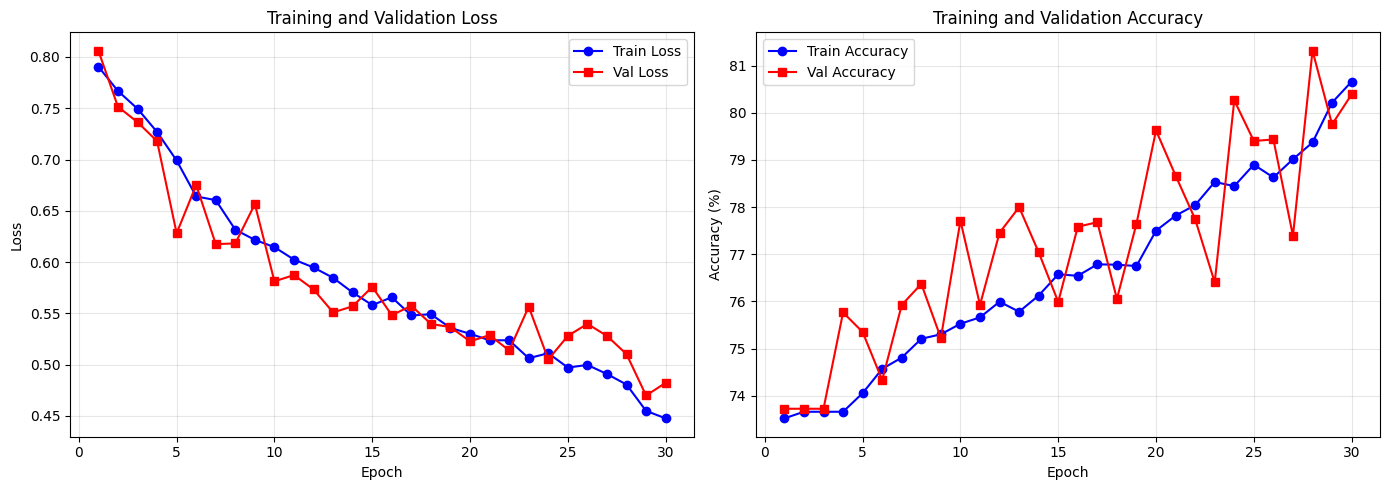

In [24]:
# plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# loss plot
ax1.plot(range(1, CONFIG['num_epochs']+1), train_losses, 'b-', label='Train Loss', marker='o')
ax1.plot(range(1, CONFIG['num_epochs']+1), val_losses, 'r-', label='Val Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# accuracy plot
ax2.plot(range(1, CONFIG['num_epochs']+1), train_accs, 'b-', label='Train Accuracy', marker='o')
ax2.plot(range(1, CONFIG['num_epochs']+1), val_accs, 'r-', label='Val Accuracy', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

In [26]:
# evaluate on validation set (all slices as independent subjects)
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for seq_imgs, labels in tqdm(val_loader, desc='Validation'):
        # seq_imgs: (batch, seq_length, 3, H, W)
        batch_size, seq_length, C, H, W = seq_imgs.shape
        seq_imgs = seq_imgs.view(-1, C, H, W).to(device)  # (batch*seq_length, 3, H, W)
        labels = labels.unsqueeze(1).repeat(1, seq_length).view(-1).to(device)  # (batch*seq_length,)
        outputs = model(seq_imgs)
        _, predicted = outputs.max(1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print('\n[ ] Overall Classification Metrics (Validation)\n')
print(f'  Accuracy:  {accuracy:.4f}')
print(f'  Precision: {precision:.4f}')
print(f'  Recall:    {recall:.4f}')
print(f'  F1-Score:  {f1:.4f}')

Validation: 100%|██████████| 98/98 [00:05<00:00, 18.44it/s]


[ ] Overall Classification Metrics (Validation)

  Accuracy:  0.8039
  Precision: 0.8024
  Recall:    0.8039
  F1-Score:  0.7991


In [ ]:
# per-class metrics (validation)

print('\n[ ] Per-Class Classification Metrics\n')
for i, class_name in enumerate(CONFIG['class_names']):
    mask = y_true == i
    if mask.sum() > 0:
        class_acc = (y_pred[mask] == i).sum() / mask.sum()

        # use binary arrays for precision/recall/f1 (one-vs-rest, no average param)
        class_prec = precision_score((y_true == i), (y_pred == i), zero_division=0)
        class_rec = recall_score((y_true == i), (y_pred == i), zero_division=0)
        class_f1 = f1_score((y_true == i), (y_pred == i), zero_division=0)
        print(f'{class_name}:')
        print(f'  Accuracy:  {class_acc:.4f}')
        print(f'  Precision: {class_prec:.4f}')
        print(f'  Recall:    {class_rec:.4f}')
        print(f'  F1-Score:  {class_f1:.4f}')


[ ] Per-Class Classification Metrics

Adenocarcinoma:
  Accuracy:  0.8932
  Precision: 0.8655
  Recall:    0.8932
  F1-Score:  0.8791

Small Cell:
  Accuracy:  0.4292
  Precision: 0.7744
  Recall:    0.4292
  F1-Score:  0.5523

Large Cell:
  Accuracy:  0.0000
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000

Squamous Cell:
  Accuracy:  0.6128
  Precision: 0.5721
  Recall:    0.6128
  F1-Score:  0.5918



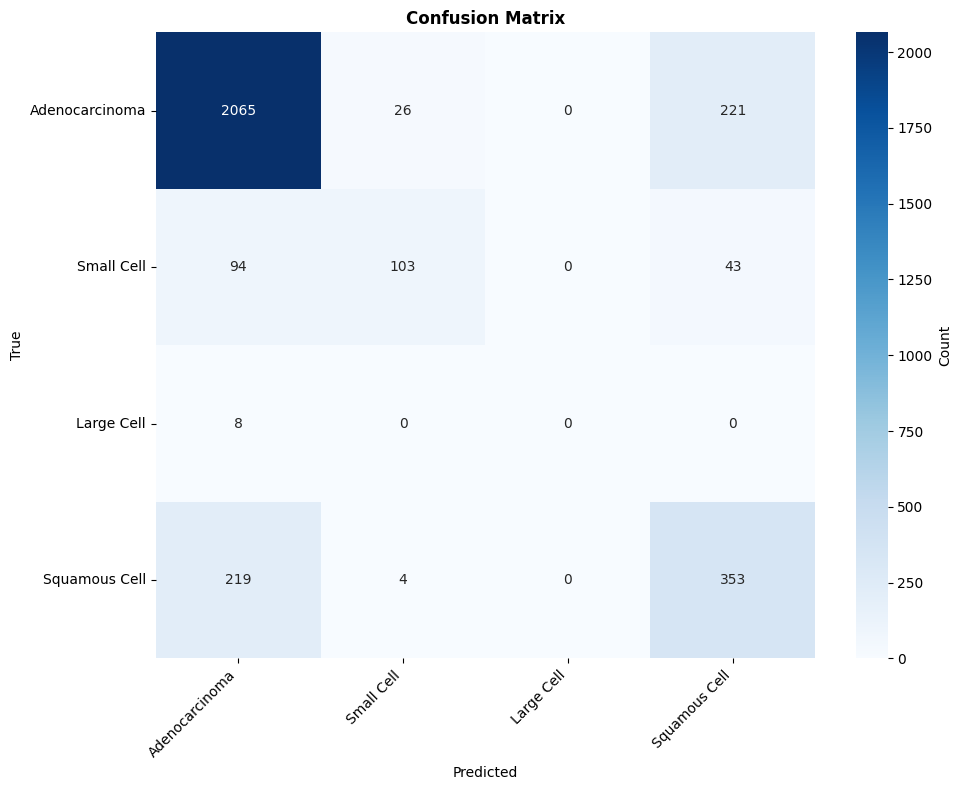

In [28]:
# confusion matrix (validation)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CONFIG['class_names'], yticklabels=CONFIG['class_names'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

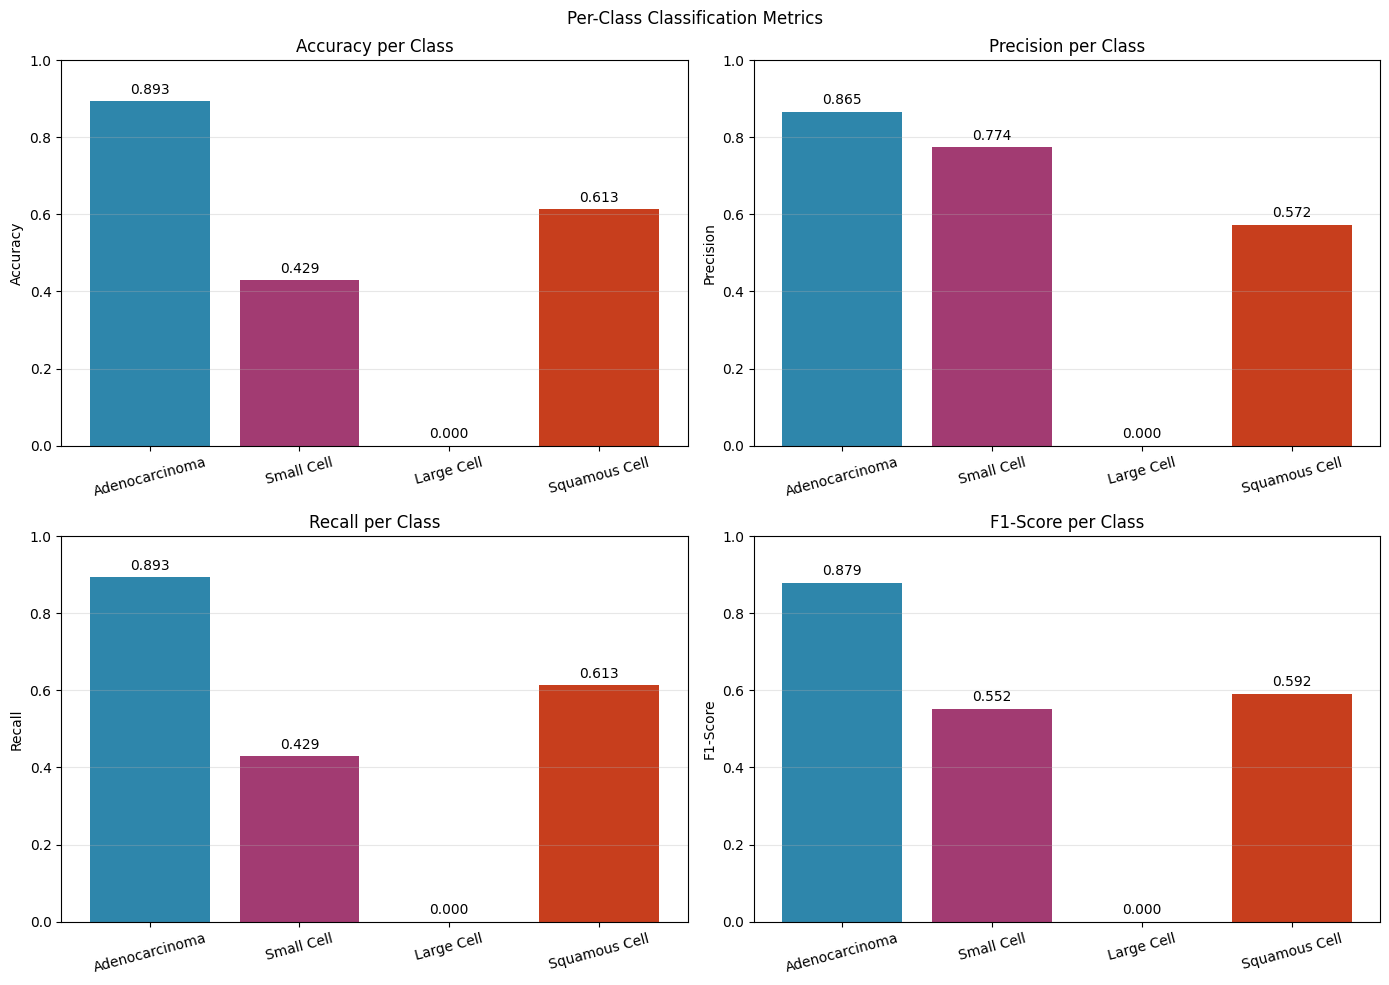

In [29]:
# per-class metrics visualization (validation)
class_accuracy_values = []
class_precision_values = []
class_recall_values = []
class_f1_values = []

for i, class_name in enumerate(CONFIG['class_names']):
    mask = y_true == i
    if mask.sum() > 0:
        class_acc = (y_pred[mask] == i).sum() / mask.sum()
        class_prec = precision_score(y_true == i, y_pred == i, zero_division=0)
        class_rec = recall_score(y_true == i, y_pred == i, zero_division=0)
        class_f1 = f1_score(y_true == i, y_pred == i, zero_division=0)
    else:
        class_acc = 0.0
        class_prec = 0.0
        class_rec = 0.0
        class_f1 = 0.0
    
    class_accuracy_values.append(class_acc)
    class_precision_values.append(class_prec)
    class_recall_values.append(class_rec)
    class_f1_values.append(class_f1)

# color palette
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# accuracy
axes[0, 0].bar(CONFIG['class_names'], class_accuracy_values, color=colors)
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Accuracy per Class')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(class_accuracy_values):
    axes[0, 0].text(i, v + 0.02, f'{v:.3f}', ha='center')
axes[0, 0].tick_params(axis='x', rotation=15)

# precision
axes[0, 1].bar(CONFIG['class_names'], class_precision_values, color=colors)
axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_title('Precision per Class')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(class_precision_values):
    axes[0, 1].text(i, v + 0.02, f'{v:.3f}', ha='center')
axes[0, 1].tick_params(axis='x', rotation=15)

# recall
axes[1, 0].bar(CONFIG['class_names'], class_recall_values, color=colors)
axes[1, 0].set_ylabel('Recall')
axes[1, 0].set_title('Recall per Class')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(class_recall_values):
    axes[1, 0].text(i, v + 0.02, f'{v:.3f}', ha='center')
axes[1, 0].tick_params(axis='x', rotation=15)

# f1-Score
axes[1, 1].bar(CONFIG['class_names'], class_f1_values, color=colors)
axes[1, 1].set_ylabel('F1-Score')
axes[1, 1].set_title('F1-Score per Class')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(class_f1_values):
    axes[1, 1].text(i, v + 0.02, f'{v:.3f}', ha='center')
axes[1, 1].tick_params(axis='x', rotation=15)

plt.suptitle('Per-Class Classification Metrics')
plt.tight_layout()
plt.show()

In [30]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

In [31]:
model.eval()
y_true_prob = []
y_scores = []

with torch.no_grad():
    for seq_imgs, labels in tqdm(test_loader, desc='Computing probabilities'):
        batch_size, seq_length, C, H, W = seq_imgs.shape
        seq_imgs = seq_imgs.view(-1, C, H, W).to(device)  # (batch*seq_length, 3, H, W)
        labels = labels.unsqueeze(1).repeat(1, seq_length).view(-1).to(device)  # (batch*seq_length,)
        outputs = model(seq_imgs)
        probs = torch.softmax(outputs, dim=1)
        
        y_true_prob.extend(labels.cpu().numpy())
        y_scores.extend(probs.cpu().numpy())

y_true_prob = np.array(y_true_prob)
y_scores = np.array(y_scores)

# binarize the labels for multi-class ROC/PR curves
y_true_bin = label_binarize(y_true_prob, classes=[0, 1, 2, 3])
n_classes = len(CONFIG['class_names'])

Computing probabilities: 100%|██████████| 98/98 [00:10<00:00,  9.50it/s]


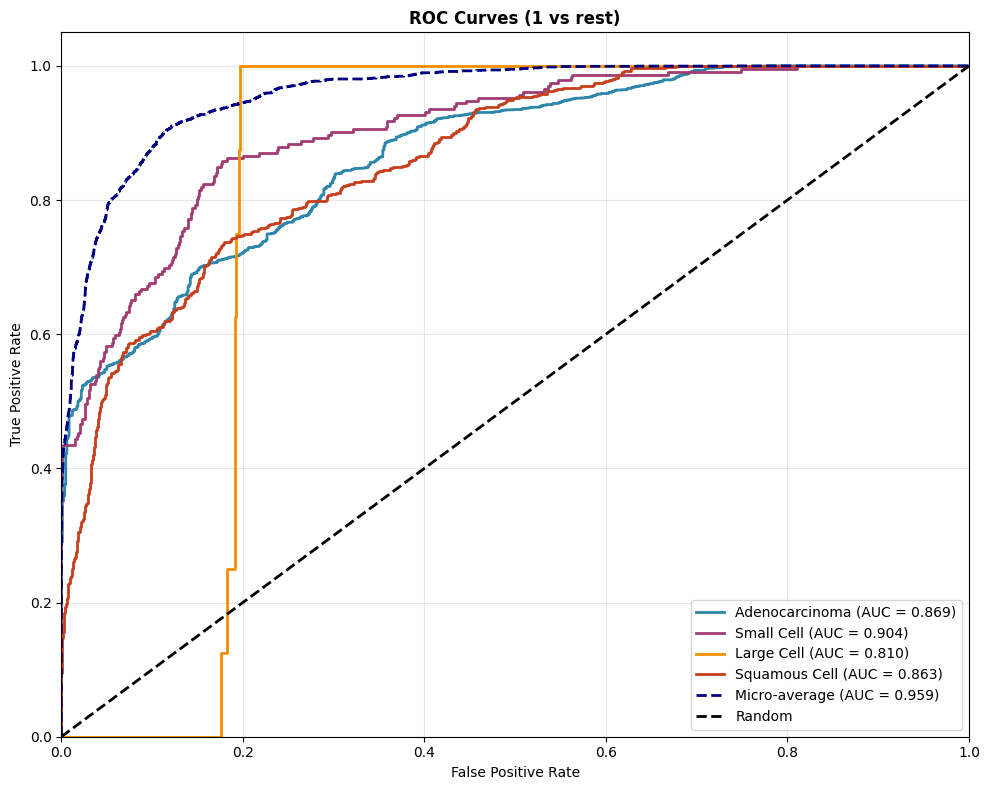


[ ] AUROC (Area Under ROC Curve)

Adenocarcinoma: 0.8692
Small Cell: 0.9040
Large Cell: 0.8104
Squamous Cell: 0.8626

Macro-average AUROC: 0.8616
Micro-average AUROC: 0.9592


In [32]:
# plot AUROC curves for each class
fig, ax = plt.subplots(figsize=(10, 8))

roc_auc = {}
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

for i, (class_name, color) in enumerate(zip(CONFIG['class_names'], colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
    roc_auc[class_name] = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, 
            label=f'{class_name} (AUC = {roc_auc[class_name]:.3f})')

# micro-average ROC curve
fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_scores.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
ax.plot(fpr_micro, tpr_micro, color='navy', lw=2, linestyle='--',
        label=f'Micro-average (AUC = {roc_auc_micro:.3f})')

# plot diagonal line
ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves (1 vs rest)', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

plt.tight_layout()
plt.show()

# print AUC values
print('\n[ ] AUROC (Area Under ROC Curve)\n')
for class_name in CONFIG['class_names']:
    print(f'{class_name}: {roc_auc[class_name]:.4f}')
print(f'\nMacro-average AUROC: {np.mean(list(roc_auc.values())):.4f}')
print(f'Micro-average AUROC: {roc_auc_micro:.4f}')


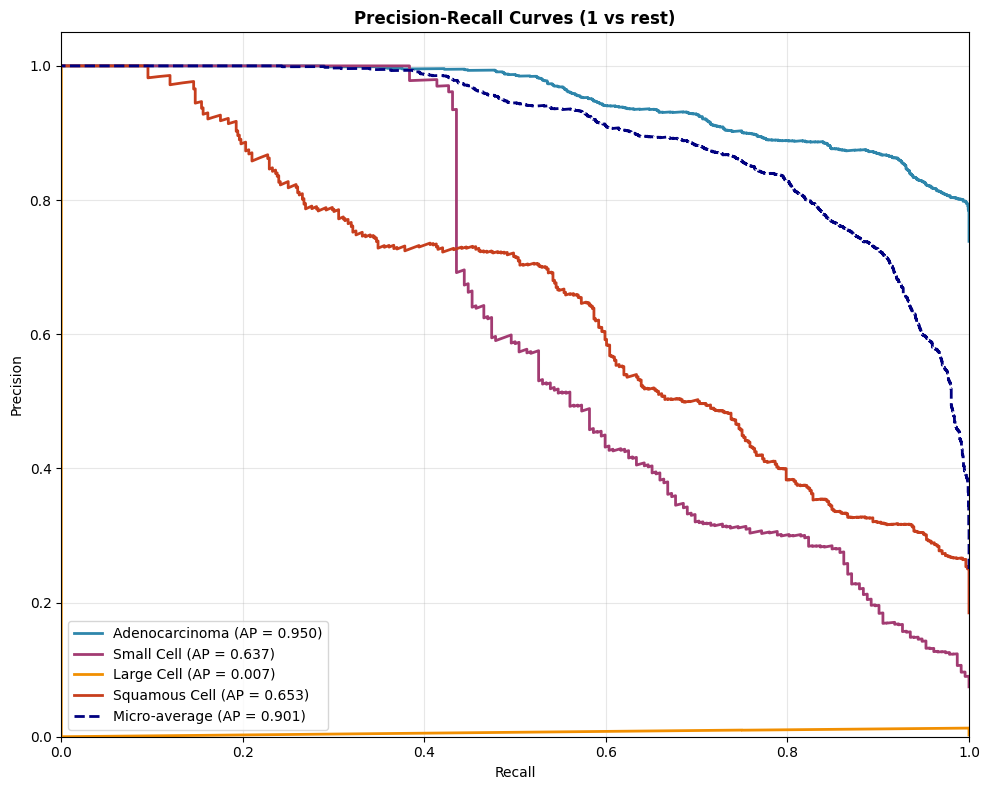


[ ] AUPRC (Area Under Precision-Recall Curve)

Adenocarcinoma: 0.9505
Small Cell: 0.6370
Large Cell: 0.0074
Squamous Cell: 0.6533

Macro-average AUPRC: 0.5621
Micro-average AUPRC: 0.9014


In [33]:
# plot AUPRC (Precision-Recall) curves for each class
fig, ax = plt.subplots(figsize=(10, 8))

pr_auc = {}

for i, (class_name, color) in enumerate(zip(CONFIG['class_names'], colors)):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_scores[:, i])
    pr_auc[class_name] = average_precision_score(y_true_bin[:, i], y_scores[:, i])
    ax.plot(recall, precision, color=color, lw=2, 
            label=f'{class_name} (AP = {pr_auc[class_name]:.3f})')

# micro-average PR curve
precision_micro, recall_micro, _ = precision_recall_curve(y_true_bin.ravel(), y_scores.ravel())
pr_auc_micro = average_precision_score(y_true_bin, y_scores, average='micro')
ax.plot(recall_micro, precision_micro, color='navy', lw=2, linestyle='--',
        label=f'Micro-average (AP = {pr_auc_micro:.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves (1 vs rest)', fontweight='bold')
ax.legend(loc='best')
ax.grid(alpha=0.3)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

plt.tight_layout()
plt.show()

# print AP values
print('\n[ ] AUPRC (Area Under Precision-Recall Curve)\n')
for class_name in CONFIG['class_names']:
    print(f'{class_name}: {pr_auc[class_name]:.4f}')
print(f'\nMacro-average AUPRC: {np.mean(list(pr_auc.values())):.4f}')
print(f'Micro-average AUPRC: {pr_auc_micro:.4f}')


In [34]:
# find optimal thresholds for each class to maximize F1 score on validation set

# get model prediction probabilities
model.eval()
y_val_true = []
y_val_scores = []

with torch.no_grad():
    for seq_imgs, labels in tqdm(val_loader, desc='Validation Threshold Search'):
        batch_size, seq_length, C, H, W = seq_imgs.shape
        seq_imgs = seq_imgs.view(-1, C, H, W).to(device)  # (batch*seq_length, 3, H, W)
        labels = labels.unsqueeze(1).repeat(1, seq_length).view(-1).to(device)  # (batch*seq_length,)
        outputs = model(seq_imgs)
        probs = torch.softmax(outputs, dim=1)
        y_val_true.extend(labels.cpu().numpy())
        y_val_scores.extend(probs.cpu().numpy())

y_val_true = np.array(y_val_true)
y_val_scores = np.array(y_val_scores)

# find best threshold for each class
best_thresholds = []
best_f1s = []
class_names = CONFIG['class_names']
for i, class_name in enumerate(class_names):
    precision, recall, thresholds = precision_recall_curve((y_val_true == i).astype(int), y_val_scores[:, i])
    f1s = 2 * (precision * recall) / (precision + recall + 1e-8)
    best_idx = np.nanargmax(f1s)
    best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    best_f1 = f1s[best_idx]
    best_thresholds.append(best_threshold)
    best_f1s.append(best_f1)
    print(f"Class {class_name}: Best threshold = {best_threshold:.3f}, F1 = {best_f1:.3f}")

# apply optimal thresholds to validation predictions
y_val_pred = []
for row in y_val_scores:
    pred = [row[i] > best_thresholds[i] for i in range(len(class_names))]
    if sum(pred) == 1:
        y_val_pred.append(np.argmax(pred))
    else:
         # fallback to max prob
        y_val_pred.append(np.argmax(row))

y_val_pred = np.array(y_val_pred)

Validation Threshold Search: 100%|██████████| 98/98 [00:05<00:00, 19.04it/s]

Class Adenocarcinoma: Best threshold = 0.419, F1 = 0.884
Class Small Cell: Best threshold = 0.605, F1 = 0.561
Class Large Cell: Best threshold = 0.013, F1 = 0.047
Class Squamous Cell: Best threshold = 0.362, F1 = 0.591


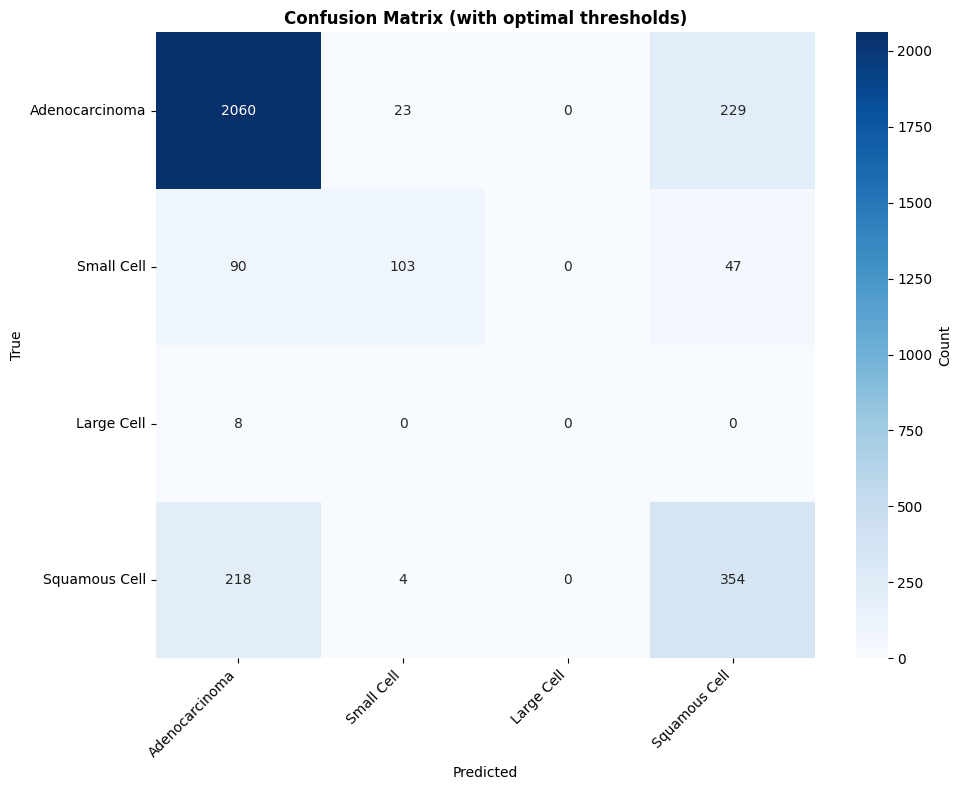

In [35]:
# confusion matrix for validation set with optimal thresholds
cm_val = confusion_matrix(y_val_true, y_val_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues',
           xticklabels=class_names, yticklabels=class_names,
           cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix (with optimal thresholds)', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [36]:
import re

In [37]:
output_dir = Path(CONFIG['model_save_dir']) / 'test_imgs'
output_dir.mkdir(parents=True, exist_ok=True)

for seq_idx in test_indices:
    seq_info = full_dataset.sequences[seq_idx]
    sequence = seq_info['sequence']  # (seq_length, H, W)
    file_base = Path(seq_info['file']).stem

    # Clean the filename
    file_base_clean = re.sub(r'(?i)^ct-?', '', file_base)
    
    for slice_idx in range(sequence.shape[0]):
        slice_2d = sequence[slice_idx]
        slice_uint8 = (slice_2d * 255).astype('uint8')
        img_pil = Image.fromarray(slice_uint8).convert('RGB')
        
        img_name = f"{file_base_clean}_seq{seq_idx}_slice{slice_idx}.png"
        img_path = output_dir / img_name
        img_pil.save(img_path)

print(f"Saved {len(test_indices) * CONFIG['seq_length']} test images to {output_dir}")
print(f"Test data split saved.")

Saved 3120 test images to ct_up_8\test_imgs
Test data split saved.
